# 14 — Explanation Stability and Additional XAI

This notebook evaluates explanation stability and extends the existing SHAP analysis
with complementary XAI methods.

The analysis focuses on the pooled Random Forest, XGBoost, and Logistic Regression
models used in the explainability stage.

The notebook includes:

1. SHAP beeswarm plots
2. SHAP dependence plots
3. Permutation importance
4. SHAP versus permutation importance comparison
5. Explanation stability across stocks, time periods, and model seeds

The expensive multi-seed SHAP calculations were completed in Notebook 13.
This notebook loads those saved results rather than recalculating them.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

In [2]:
#Load SHAP Metadata

metadata_path = ("/kaggle/input/notebooks/napatsriwiroj/13-explainability-ipynb/shap_metadata.json")

with open(metadata_path, "r") as f:
    metadata = json.load(f)

FEATURE_COLUMNS = metadata["feature_columns"]
CLASS_NAMES = metadata["class_names"]

print("Features:", len(FEATURE_COLUMNS))
print("Classes:", CLASS_NAMES)

Features: 33
Classes: ['Down', 'Neutral', 'Up']


In [3]:
#Load pooled SHAP values

shap_files = {
    "Logistic Regression":("/kaggle/input/notebooks/napatsriwiroj/13-explainability-ipynb/shap_values_pooled_logistic_regression.npz"),
    "XGBoost": ("/kaggle/input/notebooks/napatsriwiroj/13-explainability-ipynb/shap_values_pooled_xgboost.npz"),
    "Random Forest": ("/kaggle/input/notebooks/napatsriwiroj/13-explainability-ipynb/shap_values_pooled_random_forest.npz")
}

shap_arrays = {}

for model_name, path in shap_files.items():
    shap_arrays[model_name] = np.load(path)["shap_values"]
    print(model_name,shap_arrays[model_name].shape)

Logistic Regression (1130, 33, 3)
XGBoost (1130, 33, 3)
Random Forest (1130, 33, 3)


In [4]:

test_keys = pd.read_csv("/kaggle/input/notebooks/napatsriwiroj/13-explainability-ipynb/shap_row_index.csv")
display(test_keys.head())
print("Rows:", len(test_keys))

,ticker,date,row_idx
0,BRK-B,2025-01-02,0
1,BRK-B,2025-01-03,1
2,BRK-B,2025-01-06,2
3,BRK-B,2025-01-07,3
4,BRK-B,2025-01-08,4


Rows: 1130


In [5]:
DATA_PATH = "/kaggle/input/notebooks/phyothaw/06-target-and-model-dataset-ipynb/model_ready_complete_case_2020_2025.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

test_df = df[df["date"].dt.year == 2025].sort_values(
    ["ticker", "date"]
).copy()

X_test_shap = test_df[FEATURE_COLUMNS].copy()
y_test = test_df["movement_5d"].copy()

print("X_test_shap:", X_test_shap.shape)
print("y_test:", y_test.shape)

X_test_shap: (1130, 33)
y_test: (1130,)


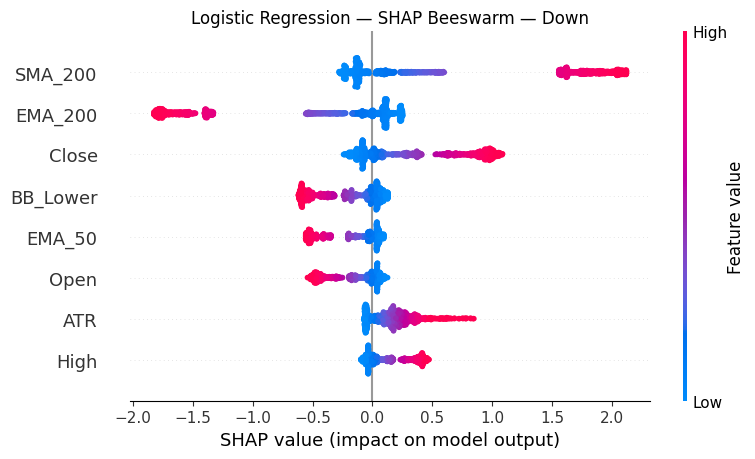

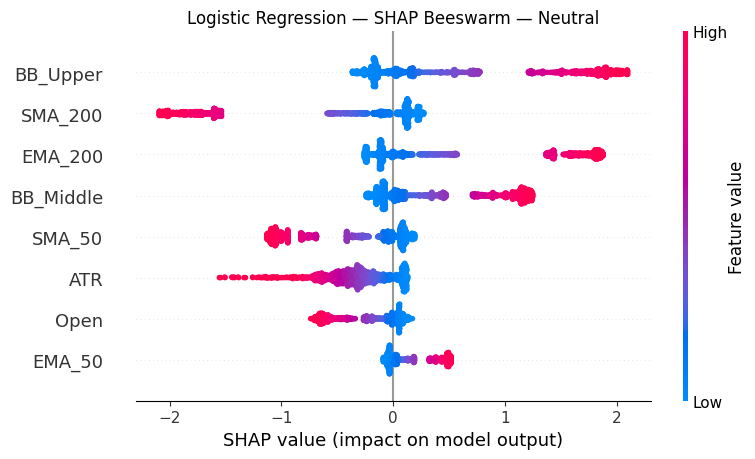

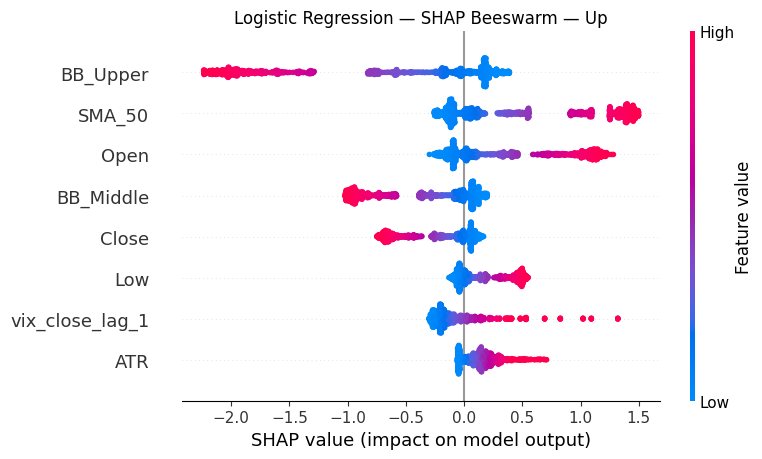

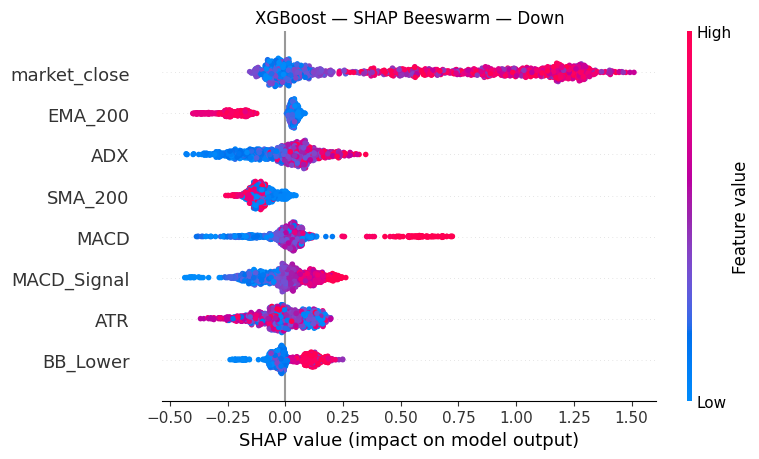

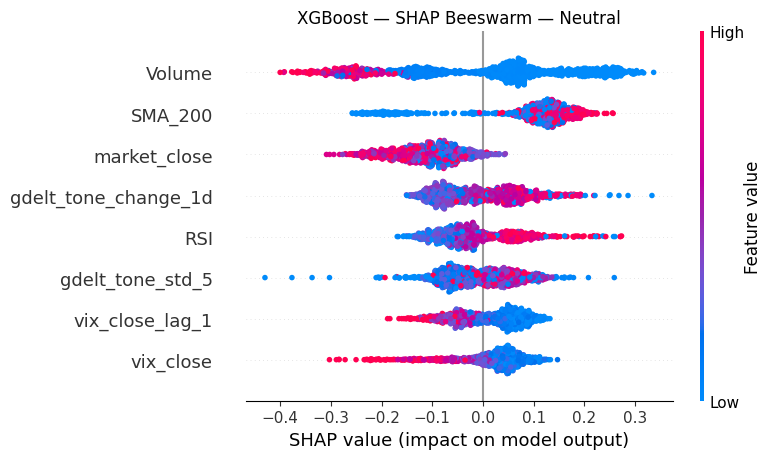

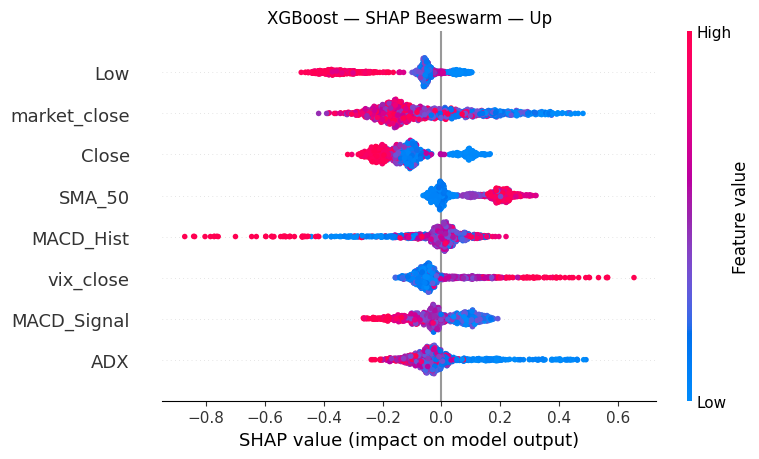

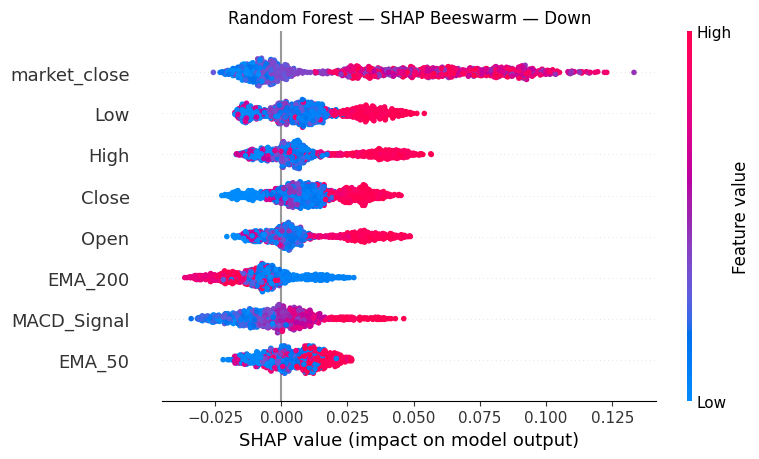

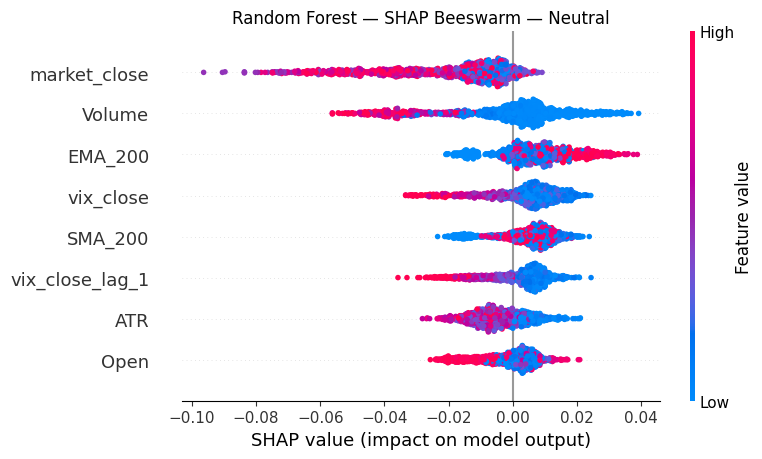

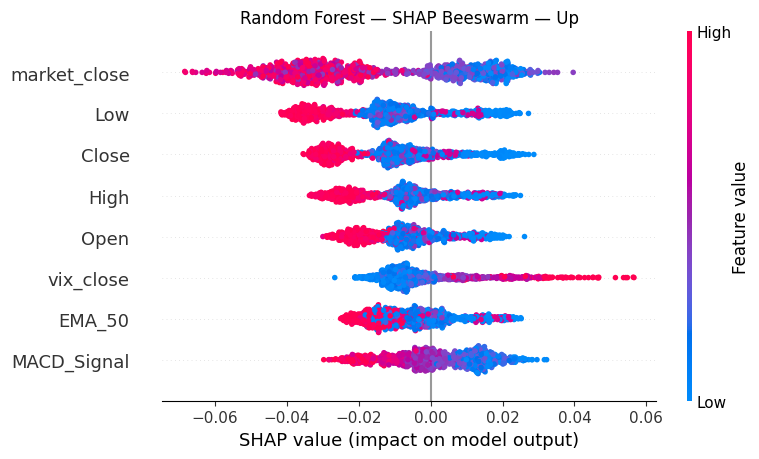

In [6]:
# ==========================================================
# SHAP Beeswarm Plots
# ==========================================================

for model_name in shap_arrays:

    shap_values = shap_arrays[model_name]

    for class_index, class_name in enumerate(CLASS_NAMES):

        plt.figure(figsize=(9, 6))

        shap.summary_plot(
            shap_values[:, :, class_index],
            X_test_shap.values,
            feature_names=FEATURE_COLUMNS,
            max_display=8,
            show=False,
            color_bar=True
        )

        plt.title(
            f"{model_name} — SHAP Beeswarm — {class_name}"
        )

        plt.tight_layout()
        plt.show()

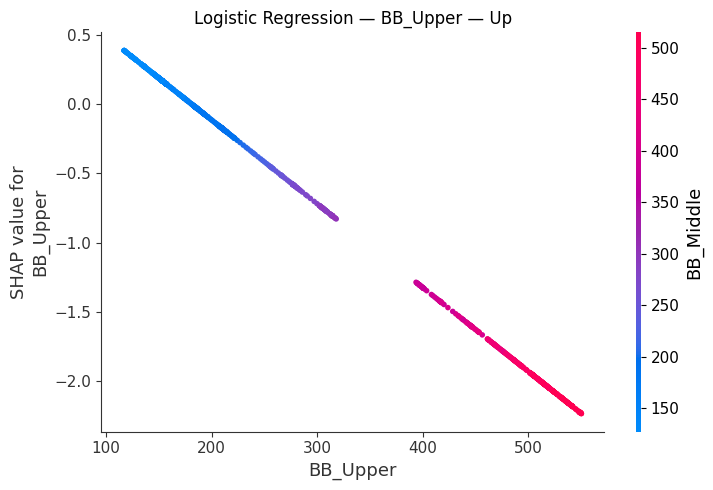

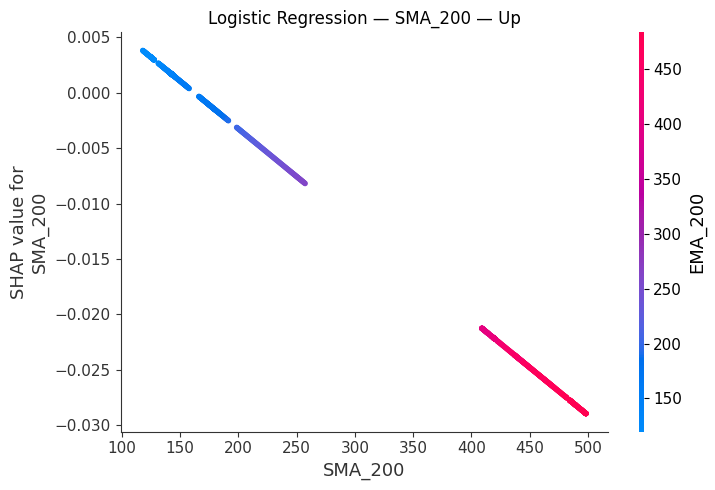

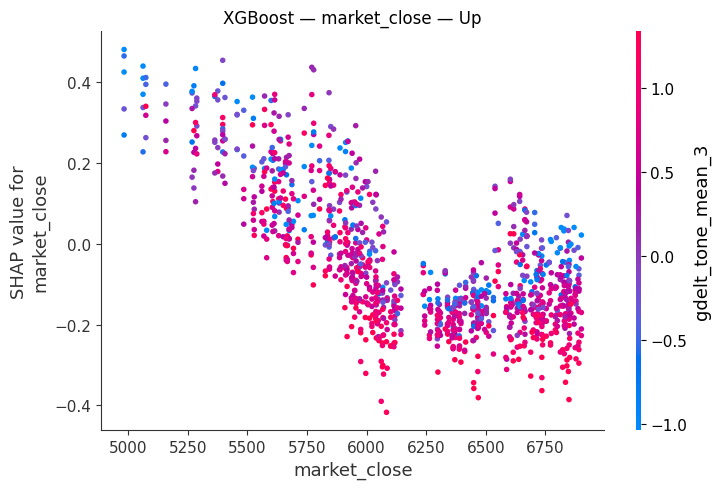

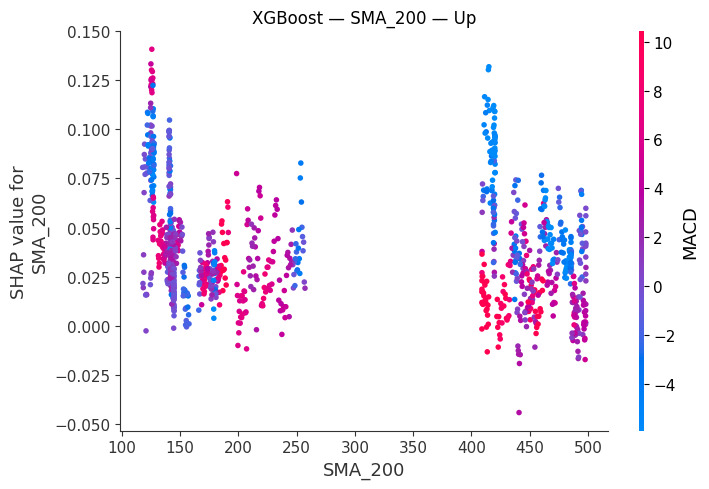

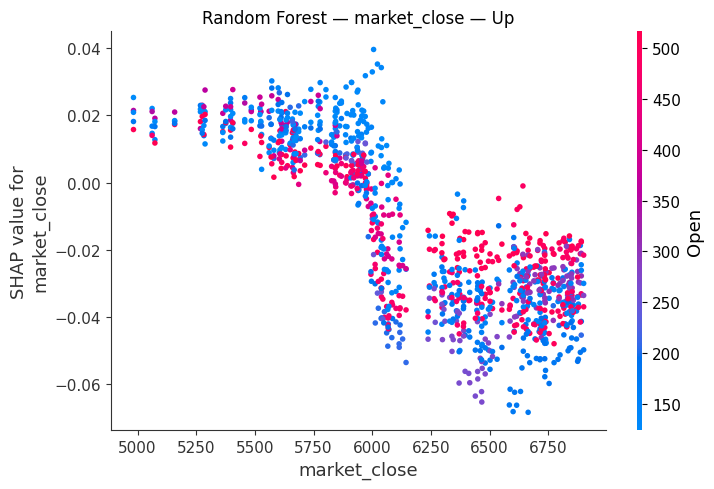

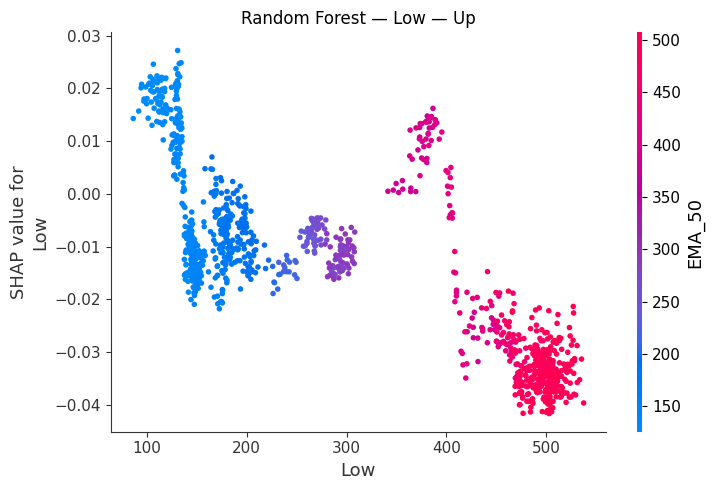

In [7]:
# ==========================================================
# SHAP Dependence Plots
# ==========================================================

os.makedirs("/kaggle/working/shap_dependence", exist_ok=True)

for model_name, shap_values in shap_arrays.items():

    importance = np.mean(np.abs(shap_values), axis=(0, 2))
    top_features = np.argsort(importance)[-2:][::-1]

    for feature_index in top_features:

        feature_name = FEATURE_COLUMNS[feature_index]

        shap.dependence_plot(
            feature_index,
            shap_values[:, :, 2],
            X_test_shap.values,
            feature_names=FEATURE_COLUMNS,
            show=False
        )

        plt.title(f"{model_name} — {feature_name} — Up")
        plt.tight_layout()

        filename = f"{model_name.replace(' ', '_')}_{feature_name}.png"
        plt.savefig(
            f"/kaggle/working/shap_dependence/{filename}",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()

## Permutation Importance

Permutation importance measures how much model performance changes when a feature is randomly shuffled.

It provides a complementary check to SHAP: SHAP explains feature contributions, while permutation importance evaluates the effect of each feature on predictive performance.

In [8]:
# ==========================================================
# Permutation Importance
# ==========================================================

from sklearn.inspection import permutation_importance
import joblib

rf_model = joblib.load("/kaggle/input/notebooks/phyothaw/09-pooled-global-model-ipynb/random_forest_model.joblib")
xgb_model = joblib.load("/kaggle/input/notebooks/phyothaw/09-pooled-global-model-ipynb/xgboost_model.joblib")
lr_model = joblib.load("/kaggle/input/notebooks/phyothaw/09-pooled-global-model-ipynb/logistic_regression_model.joblib")

In [9]:
models = {"Random Forest": rf_model, "XGBoost": xgb_model, "Logistic Regression": lr_model}

In [10]:
print(y_test.unique())
print(models["Random Forest"].classes_)

['Down' 'Neutral' 'Up']
[0 1 2]


In [11]:
y_test_perm = y_test.map({
    "Down": 0,
    "Neutral": 1,
    "Up": 2
})

print(y_test_perm.unique())
print(models["Random Forest"].classes_)

[0 1 2]
[0 1 2]


In [12]:
# Logistic Regression test data

lr_scaler = StandardScaler()

lr_scaler.fit(
    df.loc[
        df["date"].dt.year < 2025,
        FEATURE_COLUMNS
    ]
)

X_test_lr = lr_scaler.transform(X_test_shap)

y_test_perm = y_test.map({
    "Down": 0,
    "Neutral": 1,
    "Up": 2
})

print(X_test_lr.shape)

(1130, 33)


In [13]:
permutation_results = {}

for model_name, model in models.items():

    X_perm = X_test_lr if model_name == "Logistic Regression" else X_test_shap

    result = permutation_importance(
        model,
        X_perm,
        y_test_perm,
        scoring="f1_weighted",
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    permutation_results[model_name] = pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)

    print(f"\n{model_name}")
    display(permutation_results[model_name].head(10))


Random Forest


,feature,importance_mean,importance_std
8,EMA_200,0.017081,0.004394
14,BB_Middle,0.015866,0.003574
6,SMA_200,0.007386,0.004922
16,ATR,0.005497,0.006405
29,vix_change,0.005405,0.002791
7,EMA_50,0.004061,0.002260
17,ADX,0.003933,0.005897
32,vix_change_lag_1,0.002898,0.002356
20,gdelt_tone_lag_1,0.002476,0.003728
11,MACD_Signal,0.002364,0.006272



XGBoost


,feature,importance_mean,importance_std
6,SMA_200,0.013572,0.003579
8,EMA_200,0.011702,0.005877
17,ADX,0.011019,0.008786
14,BB_Middle,0.004500,0.003968
22,gdelt_tone_mean_5,0.003919,0.002483
5,SMA_50,0.003410,0.004960
24,gdelt_tone_change_1d,0.002248,0.004525
28,vix_close,0.001873,0.003990
31,vix_close_lag_1,0.001303,0.005269
27,market_return,0.000786,0.003225



Logistic Regression


,feature,importance_mean,importance_std
8,EMA_200,0.077799,0.010474
14,BB_Middle,0.059092,0.010396
13,BB_Upper,0.057051,0.009337
6,SMA_200,0.055635,0.012766
3,Close,0.034487,0.008989
1,High,0.026726,0.008252
31,vix_close_lag_1,0.018869,0.008769
16,ATR,0.016025,0.008246
7,EMA_50,0.015284,0.009787
10,MACD,0.015013,0.006226


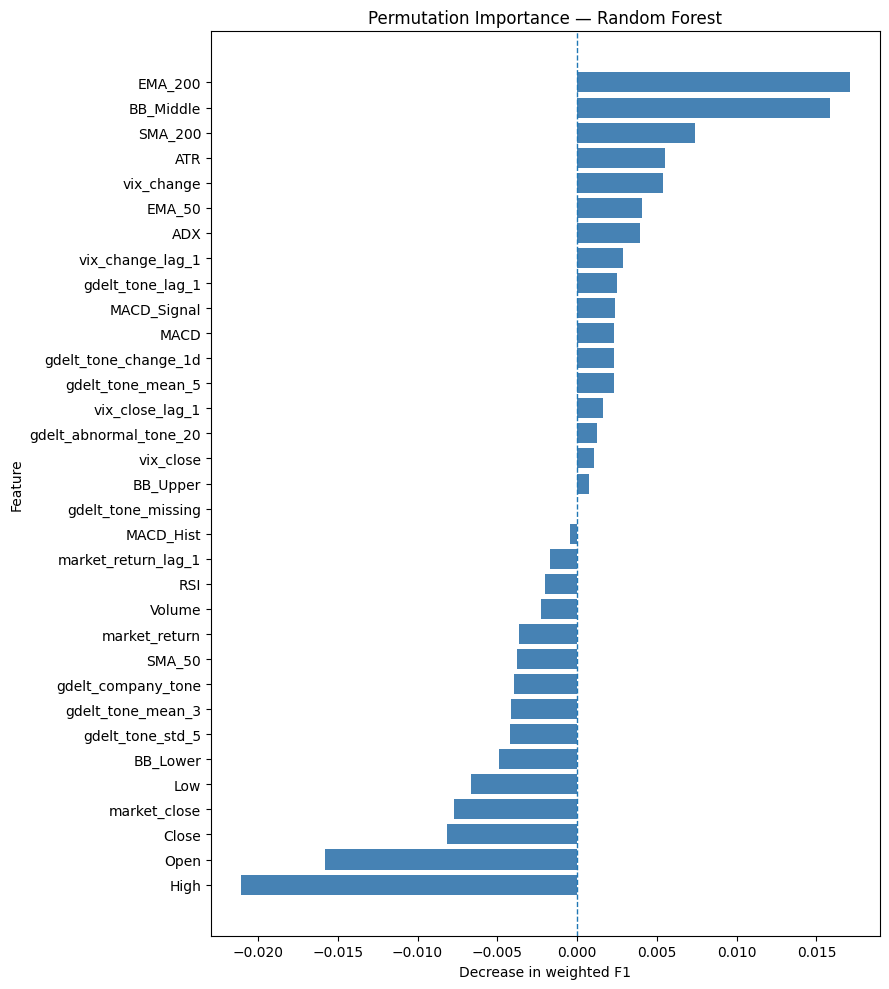

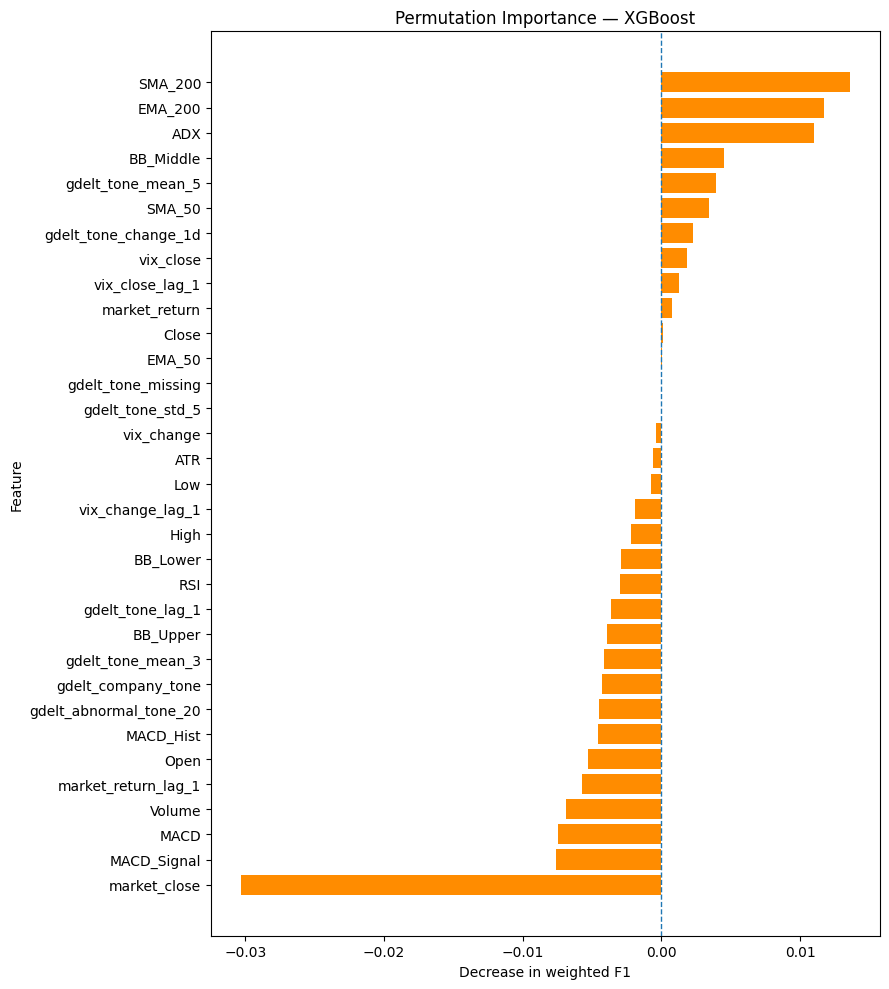

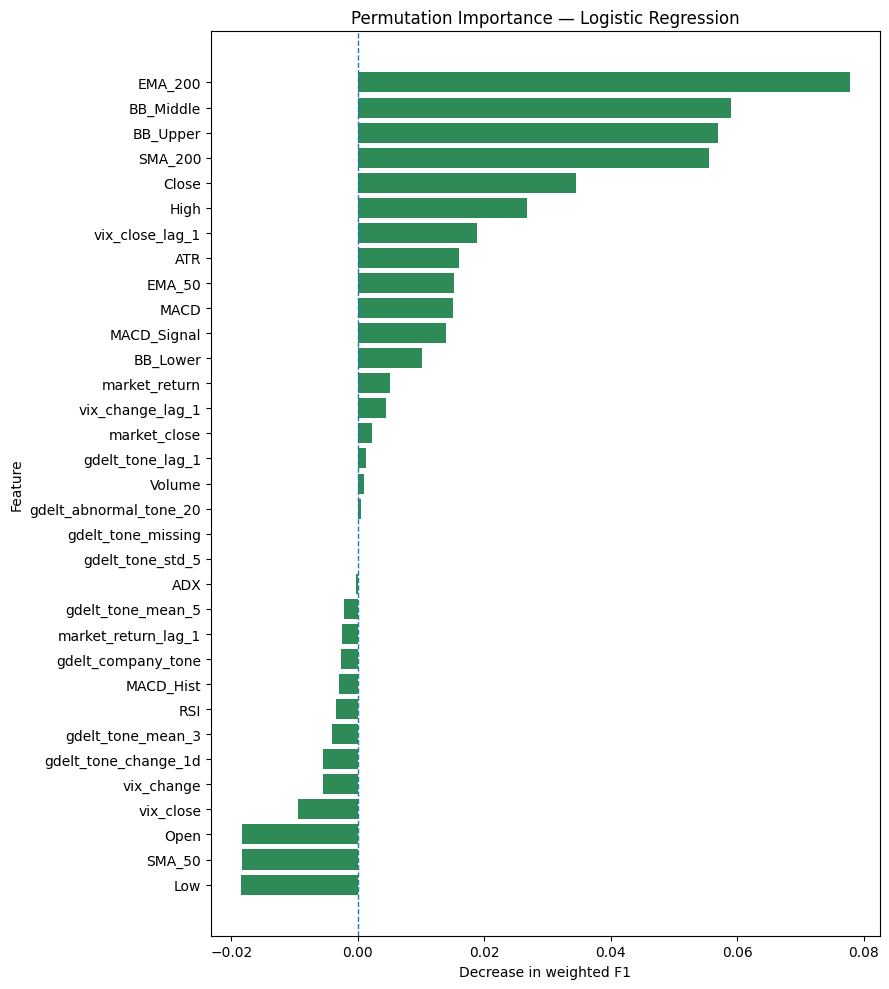

In [14]:
# Permutation Importance — all features

colors = {
    "Random Forest": "steelblue",
    "XGBoost": "darkorange",
    "Logistic Regression": "seagreen"
}

os.makedirs("/kaggle/working/permutation_importance", exist_ok=True)

for model_name, result in permutation_results.items():

    result = result.sort_values("importance_mean")

    result.to_csv(
        f"/kaggle/working/permutation_importance/{model_name.replace(' ', '_')}.csv",
        index=False
    )

    plt.figure(figsize=(9, 10))

    plt.barh(
        result["feature"],
        result["importance_mean"],
        color=colors[model_name]
    )

    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("Decrease in weighted F1")
    plt.ylabel("Feature")
    plt.title(f"Permutation Importance — {model_name}")
    plt.tight_layout()

    plt.savefig(
        f"/kaggle/working/permutation_importance/{model_name.replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [15]:
# ==========================================================
# SHAP vs Permutation Importance
# ==========================================================

shap_ranks = {}

for model_name, values in shap_arrays.items():
    mean_shap = np.abs(values).mean(axis=(0, 2))
    shap_ranks[model_name] = pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "shap_importance": mean_shap
    }).sort_values("shap_importance", ascending=False)

for model_name in permutation_results:
    comparison = shap_ranks[model_name].merge(permutation_results[model_name][["feature", "importance_mean"]],on="feature")
    comparison["shap_rank"] = comparison["shap_importance"].rank(ascending=False)
    comparison["permutation_rank"] = comparison["importance_mean"].rank(ascending=False)

print(f"\n{model_name}")
display(comparison.sort_values("shap_rank").head(10))


Logistic Regression


,feature,shap_importance,importance_mean,shap_rank,permutation_rank
0,BB_Upper,0.610268,0.057051,1.0,3.0
1,SMA_200,0.563644,0.055635,2.0,4.0
2,EMA_200,0.513451,0.077799,3.0,1.0
3,SMA_50,0.411194,-0.018358,4.0,32.0
4,BB_Middle,0.345729,0.059092,5.0,2.0
5,Open,0.332908,-0.018262,6.0,31.0
6,Close,0.291128,0.034487,7.0,5.0
7,ATR,0.239409,0.016025,8.0,8.0
8,BB_Lower,0.169474,0.010214,9.0,12.0
9,EMA_50,0.155502,0.015284,10.0,9.0


In [16]:
from scipy.stats import spearmanr

for model_name in permutation_results:

    comparison = shap_ranks[model_name].merge(
        permutation_results[model_name][["feature", "importance_mean"]],
        on="feature"
    )

    correlation, p_value = spearmanr(
        comparison["shap_importance"],
        comparison["importance_mean"]
    )

    print(
        f"{model_name}: Spearman correlation = "
        f"{correlation:.3f}, p = {p_value:.4f}"
    )

Random Forest: Spearman correlation = -0.238, p = 0.1823
XGBoost: Spearman correlation = -0.003, p = 0.9867
Logistic Regression: Spearman correlation = 0.474, p = 0.0053


### SHAP vs Permutation Importance

SHAP and permutation importance provide complementary views of feature importance. SHAP measures how features contribute to model predictions, while permutation importance measures how much model performance changes when a feature is randomly disrupted.

Spearman rank correlation was used to compare the feature rankings produced by the two methods:

- **Random Forest:** ρ = -0.238, p = 0.1823
- **XGBoost:** ρ = -0.003, p = 0.9867
- **Logistic Regression:** ρ = 0.474, p = 0.0053

The results show that explanation agreement varies substantially across models. Random Forest showed weak negative rank agreement, but the relationship was not statistically significant. XGBoost showed virtually no rank agreement between SHAP and permutation importance. In contrast, Logistic Regression showed a moderate positive and statistically significant relationship.

These findings indicate that feature-importance rankings can depend strongly on both the model and the explanation method. Therefore, SHAP and permutation importance should be treated as complementary rather than interchangeable explanations.